In [1]:
import math
import numpy as np

import torch.nn
import torch.nn.functional as F
import torch.utils.data as data_utils


import torch_geometric
from torch_geometric.nn import GCNConv

from trainer_module import *
from model_module import *
from data_module import *

In [2]:
import Bio
import Bio.PDB

# copied from https://warwick.ac.uk/fac/sci/moac/people/students/peter_cock/python/protein_contact_map/
def calc_residue_dist(residue_one, residue_two) :
    """Returns the C-alpha distance between two residues"""
    diff_vector  = residue_one["CA"].coord - residue_two["CA"].coord
    return np.sqrt(np.sum(diff_vector * diff_vector))

def calc_dist_matrix(chain_one, chain_two) :
    """Returns a matrix of C-alpha distances between two chains"""
    answer = np.zeros((len(chain_one), len(chain_two)), float)
    for row, residue_one in enumerate(chain_one) :
        for col, residue_two in enumerate(chain_two) :
            answer[row, col] = calc_residue_dist(residue_one, residue_two)
    return answer

In [3]:
struct = Bio.PDB.PDBParser().get_structure(
                file="../rosetta/SadA_NSLeu_Corrected_3701_0002.pdb", 
                id="TMP")
dist_mat = calc_dist_matrix(struct[0]["A"], struct[0]["A"])
dist_mat.shape

(273, 273)

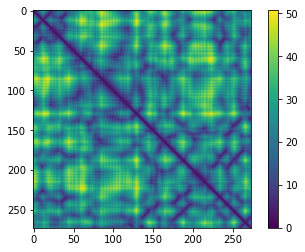

In [4]:
import matplotlib.pyplot as plt
plt.imshow(dist_mat)
plt.colorbar()
pass

In [5]:
# convert distance_matrix to adjacency matrix in torch_geometric's format

import scipy

sparse_dist_mat = scipy.sparse.coo_matrix((dist_mat < 8).astype(float))

edge_index, edge_weight = torch_geometric.utils.convert.from_scipy_sparse_matrix(sparse_dist_mat)
edge_index # includes self edges

tensor([[  0,   0,   0,  ..., 272, 272, 272],
        [  0,   1,   2,  ..., 270, 271, 272]])

In [6]:
from torch_geometric.data import Data as GeomData
from torch_geometric.loader import DataLoader as GeomDataLoader

class GeometricDataLoader(RosettaEnergiesDataModule):

    
    def train_dataloader(self):
        return GeomDataLoader([GeomData(x=x[0], y=x[1], 
                                        num_nodes=self.slen, edge_index=edge_index) for x in self.train_data],
                batch_size=self.batch_size, shuffle=True,
                num_workers=self.num_workers)

    def val_dataloader(self):
        return GeomDataLoader([GeomData(x=x[0], y=x[1], 
                                               num_nodes=self.slen, edge_index=edge_index) for x in self.val_data],
                batch_size=self.batch_size, num_workers=self.num_workers)

    def test_dataloader(self):
        # make sure shuffle is off here
        return GeomDataLoader([GeomData(x=x[0], y=x[1],
                                               num_nodes=self.slen, edge_index=edge_index) for x in self.test_data],
                batch_size=self.batch_size, num_workers=self.num_workers)

In [7]:
# dm = GeometricDataLoader(parent="2D", num_variants=1000)
# dm.setup()

# for batch in dm.train_dataloader():
#     print(batch)
#     break

In [8]:
class GCNRosettaEnergyPrediction(RosettaEnergyPrediction):
    
    def __init__(self,
                slen,  # sequence length (get from data_module dm.slen)
                nparam, # number of energy terms to predict (dm.nparam)
                embed_ncomp=0,  # 0 means one-hot, >0 means PCA encoding
                embed_freeze=True, # whether the embedding is trainable or not
                learning_rate=0.01,
                ):
        super().__init__(slen=slen, nparam=nparam, embed_ncomp=embed_ncomp, 
                         embed_freeze=embed_freeze, learning_rate=learning_rate)

    
    def setup_layers(self):
        edim = self.edim
        self.gc1 = GCNConv(in_channels=edim, out_channels=2*edim)
        self.gc2 = GCNConv(in_channels=2*edim, out_channels=4*edim)
        self.linear_1 = torch.nn.Linear(self.slen * 4*edim, self.nparam)

    def shared_step(self, batch):
        x, y = batch.x, batch.y
        # pass through network
        out = self(batch)
        y = y.reshape(-1, self.nparam)
        # calculate loss
        return nn.MSELoss()(out, y)
    
    def predict_step(self, batch, batch_idx):
        x, y = batch.x, batch.y
        y = y.reshape(-1, self.nparam)        
        return self(batch), y
        
    def forward(self, batch):
        #print(batch.x.shape)
        x = self.embed(batch.x)
        #print("After embed : ", x.shape)
        #x = x.permute(0,2,1) # swap length and channel dims
        #print("After swap : ", x.shape)
        x = self.gc1(x, batch.edge_index)
        #print("After GC1 : ", x.shape)
        x = F.relu(x)
        #print("After Relu : ", x.shape)
        x = self.gc2(x, batch.edge_index)
        #print("After GC2 : ", x.shape)
        x = F.relu(x)
        #print("After Relu : ", x.shape)
        x = x.reshape(-1, self.slen * 4*self.edim)
        #print("After reshape : ", x.shape)
        x = self.linear_1(x)
        #print("After linear : ", x.shape)
        return x

In [9]:
seed = 1111
log_dir="../data/scratch/rosetta/training_logs"
gpus=0
max_epochs=50
num_variants=10000
embed_ncomp=8
embed_freeze=False

pl.utilities.seed.seed_everything(seed)
logger = CSVLogger(log_dir, name='RosettaEnergiesTraining')
#dm = RosettaEnergiesDataModule(parent="2D", num_variants=num_variants)
dm = GeometricDataLoader(parent="2D", num_variants=num_variants)

trainer = pl.Trainer(logger=logger, max_epochs=max_epochs,
                        gpus=gpus)
# initialize model from the model_name
model = GCNRosettaEnergyPrediction(slen=dm.slen,
                    nparam=dm.nparam, embed_ncomp=embed_ncomp,
                    embed_freeze=embed_freeze)
trainer.fit(model, dm)

Global seed set to 1111
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs

  | Name     | Type      | Params
---------------------------------------
0 | embed    | Embedding | 160   
1 | gc1      | GCNConv   | 144   
2 | gc2      | GCNConv   | 544   
3 | linear_1 | Linear    | 157 K 
---------------------------------------
158 K     Trainable params
0         Non-trainable params
158 K     Total params
0.632     Total estimated model params size (MB)


/home/romeroroot/miniconda3/lib/python3.9/site-packages/pytorch_lightning/utilities/data.py:59: UserWarning: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 1. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
  warning_cache.warn(
Global seed set to 1111


Epoch 0:  89% 251/282 [00:27<00:03,  9.11it/s, loss=27.9, v_num=74]   
Validating: 0it [00:00, ?it/s]
Validating:   0% 0/32 [00:00<?, ?it/s]
Epoch 0:  90% 253/282 [00:27<00:03,  9.12it/s, loss=27.9, v_num=74]
Epoch 0:  91% 256/282 [00:27<00:02,  9.18it/s, loss=27.9, v_num=74]
Epoch 0:  92% 259/282 [00:28<00:02,  9.25it/s, loss=27.9, v_num=74]
Epoch 0:  93% 262/282 [00:28<00:02,  9.31it/s, loss=27.9, v_num=74]
Epoch 0:  94% 265/282 [00:28<00:01,  9.37it/s, loss=27.9, v_num=74]
Epoch 0:  95% 268/282 [00:28<00:01,  9.44it/s, loss=27.9, v_num=74]
Epoch 0:  96% 271/282 [00:28<00:01,  9.50it/s, loss=27.9, v_num=74]
Epoch 0:  97% 274/282 [00:28<00:00,  9.57it/s, loss=27.9, v_num=74]
Epoch 0:  98% 277/282 [00:28<00:00,  9.63it/s, loss=27.9, v_num=74]
Epoch 0:  99% 280/282 [00:28<00:00,  9.70it/s, loss=27.9, v_num=74]
Epoch 0: 100% 282/282 [00:28<00:00,  9.73it/s, loss=27.9, v_num=74]
Epoch 1:  89% 250/282 [00:27<00:03,  9.15it/s, loss=90.7, v_num=74]
Validating: 0it [00:00, ?it/s]
Validating: 

Validating:   0% 0/32 [00:00<?, ?it/s]
Epoch 9:  89% 252/282 [00:26<00:03,  9.34it/s, loss=16.6, v_num=74]
Epoch 9:  90% 255/282 [00:27<00:02,  9.41it/s, loss=16.6, v_num=74]
Epoch 9:  91% 258/282 [00:27<00:02,  9.47it/s, loss=16.6, v_num=74]
Epoch 9:  93% 261/282 [00:27<00:02,  9.54it/s, loss=16.6, v_num=74]
Epoch 9:  94% 264/282 [00:27<00:01,  9.61it/s, loss=16.6, v_num=74]
Epoch 9:  95% 267/282 [00:27<00:01,  9.67it/s, loss=16.6, v_num=74]
Epoch 9:  96% 270/282 [00:27<00:01,  9.74it/s, loss=16.6, v_num=74]
Epoch 9:  97% 273/282 [00:27<00:00,  9.81it/s, loss=16.6, v_num=74]
Epoch 9:  98% 276/282 [00:27<00:00,  9.88it/s, loss=16.6, v_num=74]
Epoch 9:  99% 279/282 [00:28<00:00,  9.94it/s, loss=16.6, v_num=74]
Epoch 9: 100% 282/282 [00:28<00:00,  9.99it/s, loss=16.6, v_num=74]
Epoch 10:  89% 250/282 [00:26<00:03,  9.52it/s, loss=16.9, v_num=74]
Validating: 0it [00:00, ?it/s]
Validating:   0% 0/32 [00:00<?, ?it/s]
Epoch 10:  89% 252/282 [00:26<00:03,  9.54it/s, loss=16.9, v_num=74]
Epoch

Epoch 18:  89% 252/282 [00:26<00:03,  9.68it/s, loss=25.9, v_num=74]
Epoch 18:  90% 255/282 [00:26<00:02,  9.75it/s, loss=25.9, v_num=74]
Epoch 18:  91% 258/282 [00:26<00:02,  9.82it/s, loss=25.9, v_num=74]
Epoch 18:  93% 261/282 [00:26<00:02,  9.90it/s, loss=25.9, v_num=74]
Epoch 18:  94% 264/282 [00:26<00:01,  9.97it/s, loss=25.9, v_num=74]
Epoch 18:  95% 267/282 [00:26<00:01, 10.04it/s, loss=25.9, v_num=74]
Epoch 18:  96% 270/282 [00:26<00:01, 10.11it/s, loss=25.9, v_num=74]
Epoch 18:  97% 273/282 [00:26<00:00, 10.18it/s, loss=25.9, v_num=74]
Epoch 18:  98% 276/282 [00:26<00:00, 10.25it/s, loss=25.9, v_num=74]
Epoch 18:  99% 279/282 [00:27<00:00, 10.32it/s, loss=25.9, v_num=74]
Epoch 18: 100% 282/282 [00:27<00:00, 10.38it/s, loss=25.9, v_num=74]
Epoch 19:  89% 250/282 [00:27<00:03,  9.14it/s, loss=17.7, v_num=74]
Validating: 0it [00:00, ?it/s]
Validating:   0% 0/32 [00:00<?, ?it/s]
Epoch 19:  89% 252/282 [00:27<00:03,  9.16it/s, loss=17.7, v_num=74]
Epoch 19:  90% 255/282 [00:27<00:

Epoch 27:  89% 252/282 [00:26<00:03,  9.46it/s, loss=15.3, v_num=74]
Epoch 27:  90% 255/282 [00:26<00:02,  9.52it/s, loss=15.3, v_num=74]
Epoch 27:  91% 258/282 [00:26<00:02,  9.59it/s, loss=15.3, v_num=74]
Epoch 27:  93% 261/282 [00:27<00:02,  9.65it/s, loss=15.3, v_num=74]
Epoch 27:  94% 264/282 [00:27<00:01,  9.72it/s, loss=15.3, v_num=74]
Epoch 27:  95% 267/282 [00:27<00:01,  9.79it/s, loss=15.3, v_num=74]
Epoch 27:  96% 270/282 [00:27<00:01,  9.86it/s, loss=15.3, v_num=74]
Epoch 27:  97% 273/282 [00:27<00:00,  9.93it/s, loss=15.3, v_num=74]
Epoch 27:  98% 276/282 [00:27<00:00, 10.00it/s, loss=15.3, v_num=74]
Epoch 27:  99% 279/282 [00:27<00:00, 10.07it/s, loss=15.3, v_num=74]
Epoch 27: 100% 282/282 [00:27<00:00, 10.12it/s, loss=15.3, v_num=74]
Epoch 28:  89% 250/282 [00:25<00:03,  9.69it/s, loss=49.3, v_num=74]
Validating: 0it [00:00, ?it/s]
Validating:   0% 0/32 [00:00<?, ?it/s]
Epoch 28:  89% 252/282 [00:25<00:03,  9.72it/s, loss=49.3, v_num=74]
Epoch 28:  90% 255/282 [00:26<00:

Epoch 36:  90% 255/282 [00:28<00:03,  8.90it/s, loss=53.9, v_num=74]
Epoch 36:  91% 258/282 [00:28<00:02,  8.96it/s, loss=53.9, v_num=74]
Epoch 36:  93% 261/282 [00:28<00:02,  9.03it/s, loss=53.9, v_num=74]
Epoch 36:  94% 264/282 [00:29<00:01,  9.09it/s, loss=53.9, v_num=74]
Epoch 36:  95% 267/282 [00:29<00:01,  9.16it/s, loss=53.9, v_num=74]
Epoch 36:  96% 270/282 [00:29<00:01,  9.22it/s, loss=53.9, v_num=74]
Epoch 36:  97% 273/282 [00:29<00:00,  9.28it/s, loss=53.9, v_num=74]
Epoch 36:  98% 276/282 [00:29<00:00,  9.34it/s, loss=53.9, v_num=74]
Epoch 36:  99% 279/282 [00:29<00:00,  9.40it/s, loss=53.9, v_num=74]
Epoch 36: 100% 282/282 [00:29<00:00,  9.45it/s, loss=53.9, v_num=74]
Epoch 37:  89% 250/282 [00:26<00:03,  9.29it/s, loss=34.9, v_num=74]
Validating: 0it [00:00, ?it/s]
Validating:   0% 0/32 [00:00<?, ?it/s]
Epoch 37:  89% 252/282 [00:27<00:03,  9.31it/s, loss=34.9, v_num=74]
Epoch 37:  90% 255/282 [00:27<00:02,  9.38it/s, loss=34.9, v_num=74]
Epoch 37:  91% 258/282 [00:27<00:

Epoch 45:  90% 255/282 [00:26<00:02,  9.54it/s, loss=26.8, v_num=74]
Epoch 45:  91% 258/282 [00:26<00:02,  9.60it/s, loss=26.8, v_num=74]
Epoch 45:  93% 261/282 [00:27<00:02,  9.66it/s, loss=26.8, v_num=74]
Epoch 45:  94% 264/282 [00:27<00:01,  9.73it/s, loss=26.8, v_num=74]
Epoch 45:  95% 267/282 [00:27<00:01,  9.79it/s, loss=26.8, v_num=74]
Epoch 45:  96% 270/282 [00:27<00:01,  9.85it/s, loss=26.8, v_num=74]
Epoch 45:  97% 273/282 [00:27<00:00,  9.92it/s, loss=26.8, v_num=74]
Epoch 45:  98% 276/282 [00:27<00:00,  9.98it/s, loss=26.8, v_num=74]
Epoch 45:  99% 279/282 [00:27<00:00, 10.05it/s, loss=26.8, v_num=74]
Epoch 45: 100% 282/282 [00:27<00:00, 10.11it/s, loss=26.8, v_num=74]
Epoch 45: 100% 282/282 [00:27<00:00, 10.09it/s, loss=26.8, v_num=74]
Epoch 46:  89% 250/282 [00:26<00:03,  9.30it/s, loss=16.2, v_num=74]
Validating: 0it [00:00, ?it/s]
Validating:   0% 0/32 [00:00<?, ?it/s]
Epoch 46:  89% 252/282 [00:27<00:03,  9.32it/s, loss=16.2, v_num=74]
Epoch 46:  90% 255/282 [00:27<00:

In [10]:
predictions, values = get_predictions(trainer, model, dm)

Predicting: 250it [00:01, ?it/s]


In [11]:
import matplotlib.pyplot as plt

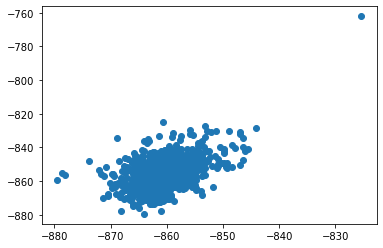

In [12]:
plt.scatter(predictions, values)

In [13]:
import scipy as sp
sp.stats.pearsonr(predictions, values)

(0.48230843277867874, 2.174429968093685e-59)

In [14]:
sp.stats.spearmanr(predictions, values)

SpearmanrResult(correlation=0.41551664348904294, pvalue=5.099154269573487e-43)